# 01 - Build the whole cluster

Every result this project has produced so far was measured on **51 GPU nodes**:
23,618 jobs, 6,312 of them failing, 2,098 of those long enough to produce a
20-minute window. `headroom/` finished by diagnosing that number as the binding
constraint - not the architecture, not the features, not co-tenancy. The
permutation control there showed that shuffled labels reach train AP 0.944, so the
915,508 training windows carry roughly as much independent information as the
~10,265 jobs they came from.

That diagnosis makes a prediction, and the dataset can test it. The same 68 days
contain **257,012 non-GPU jobs** that this project has never touched:

| | jobs | failing | OUT_OF_MEMORY | snapshots |
|---|---|---|---|---|
| GPU (everything so far) | 23,618 | 6,312 | 130 | 11,144,842 |
| non-GPU (never used) | 257,012 | 54,138 | 4,499 | 74,295,588 |
| **multiplier** | **10.9x** | **8.6x** | **34.6x** | **6.7x** |

This notebook builds the same windowed dataset over **all 343 nodes**, using the
identical window definition, labelling rule and temporal split. Nothing about the
method changes. Only the sample size does.

## The one thing that has to change: the feature set

The five `nvidia_gpu_*` metrics are **exactly zero** on non-GPU nodes - constant, one
distinct value per part. They cannot be part of a shared feature set. What survives is
the **9 node-level metrics** the two hardware types have in common:

`mem_free, mem_active, mem_dirty, load1, procs_running, procs_blocked, node_power,
disk_written_rate, net_rx_rate` -> x {min, max, mean, std} = **36 features**.

This is a deliberate restriction. Extra CPU-side columns exist and could be added, but
then "more data" and "more features" would move together and neither could be
attributed. The comparison this folder wants is **the same 36 columns on 8.6x more
failing jobs**, so the GPU-only baseline is re-measured on those 36 columns too, not
quoted from `headroom/`, whose numbers used 56 columns including the GPU ones.

## Pre-registration

Written before the build runs, and reported however it lands.

**B1.** The build will produce **more than 6 million** windows and **more than 15,000
failing jobs with at least one complete window**, against 2,098 on GPU nodes.

**B2.** The window-level positive rate will be **lower** than the GPU population's
3.26 %, because non-GPU jobs are shorter on average, so a smaller share of their
telemetry sits inside the 2-hour horizon.

**B3.** The failure *mix* will differ: `OUT_OF_MEMORY` is 2.1 % of GPU failures but
8.3 % of non-GPU failures, and OOM is the one mode with a demonstrated telemetry
precursor. If the mix holds after windowing, this population is structurally more
favourable to the technique, not just larger.

## What is not done here

No model is trained in this notebook. It builds `data/jobs_all.parquet` and
`data/windows_all.parquet` and stops. `02` runs the scale test, `03` the OOM question,
`04` the final protocol.

In [1]:
# --- Setup ------------------------------------------------------------------
# Repeated verbatim at the top of every notebook in this folder so each one can be
# read and run on its own. The notebooks share data files, never code.
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW  = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# --- Pipeline constants: identical to eda/ and headroom/ ---------------------
WINDOW     = 40     # snapshots per window -> 20 minutes at a 30 s cadence
HORIZON_H  = 2.0    # a snapshot is positive within 2 h of a failing job's end
GAP_TOL_S  = 60.0   # reject any window that contains a larger gap than this
STRIDE     = 10     # keep every 10th window start inside a series
TRAIN_FRAC = 0.8    # temporal split: the first 80 % of jobs by end_date
SNAP_S     = 30.0

# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran out
# of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

PARTS = sorted(RAW.glob("part-*.parquet"))
print(f"dataset: {len(PARTS)} parts")

dataset: 200 parts


In [2]:
# --- The 9 metrics the two hardware types share -----------------------------
# The GPU columns are dropped because they are identically zero on 292 of the 343
# nodes; keeping them would let the model tell the hardware types apart through a
# column that carries no information on one of them.
RAW_METRICS = {                                   # metric name -> parquet column
    "mem_free":      "node_memory_MemFree_bytes",
    "mem_active":    "node_memory_Active_bytes",
    "mem_dirty":     "node_memory_Dirty_bytes",
    "load1":         "node_load1",
    "procs_running": "node_procs_running",
    "procs_blocked": "node_procs_blocked",
    "node_power":    "node_power_usage",
}
# Cumulative counters: the raw value mostly encodes node uptime, so it is
# differenced into a per-second rate before windowing.
CUM_METRICS = {"disk_written_rate": "node_disk_written_bytes_total_sum",
               "net_rx_rate":       "node_network_receive_bytes_total_sum"}
METRICS  = list(RAW_METRICS) + list(CUM_METRICS)
AGGS     = ["min", "max", "mean", "std"]
FEATURES = [f"{m}__{a}" for m in METRICS for a in AGGS]
KEY = ["slurm_id", "node", "timestamp", "state", "end_date", "nodetypes",
       "numnodes", "gpu_node"]
SRC = list(RAW_METRICS.values()) + list(CUM_METRICS.values())
print(f"{len(METRICS)} metrics x {len(AGGS)} aggregations = {len(FEATURES)} features")

9 metrics x 4 aggregations = 36 features


## Step 1 - The job table for the whole cluster

One streaming pass over the 200 parts, grouping each part down to one row per
`(job, node)` series before anything is concatenated, so the 94-million-row table is
never materialised. `CANCELLED` is dropped here as everywhere else in the project: a
user pressing Ctrl-C is not a failure to predict.

The parts turn out to be sorted by node - asserted below - which is what makes the
chunked window build in step 2 correct.

In [3]:
t0 = time.time()
CENSUS_COLS = ["slurm_id", "node", "timestamp", "state", "end_date", "start_date",
               "nodetypes", "numnodes", "numcores", "gpu_node"]
pieces = []
node_hi = None
for i, p in enumerate(PARTS):
    t = pq.read_table(p, columns=CENSUS_COLS)
    t = t.filter(pc.field("state") != "CANCELLED")
    if t.num_rows == 0:
        continue
    lo = pc.min(t.column("node")).as_py()
    assert node_hi is None or lo >= node_hi, f"parts are not node-sorted at {p.name}"
    node_hi = pc.max(t.column("node")).as_py()
    g = t.group_by(["slurm_id", "node", "state", "gpu_node", "nodetypes",
                    "numnodes", "numcores"]).aggregate(
        [("timestamp", "min"), ("timestamp", "max"), ("timestamp", "count"),
         ("start_date", "min"), ("end_date", "min")])
    pieces.append(g)
    if (i + 1) % 50 == 0:
        print(f"  {i+1:3d}/{len(PARTS)} parts   [{time.time()-t0:.0f}s]")

S = pa.concat_tables(pieces).to_pandas(); del pieces; gc.collect()
S = (S.rename(columns={"timestamp_count": "n_snap"})
       .groupby(["slurm_id", "node", "state", "gpu_node", "nodetypes",
                 "numnodes", "numcores"], observed=True)
       .agg(first_ts=("timestamp_min", "min"), last_ts=("timestamp_max", "max"),
            n_snap=("n_snap", "sum"), start_date=("start_date_min", "min"),
            end_date=("end_date_min", "min"))
       .reset_index())
print(f"{len(S):,} (job, node) series in {time.time()-t0:.0f}s")

   50/200 parts   [6s]


  100/200 parts   [11s]


  150/200 parts   [17s]


  200/200 parts   [23s]


312,885 (job, node) series in 24s


In [4]:
# --- one row per job, and the temporal split --------------------------------
jobs = (S.groupby("slurm_id", observed=True)
          .agg(state=("state", "first"), gpu_node=("gpu_node", "max"),
               nodetypes=("nodetypes", "first"), numnodes=("numnodes", "first"),
               numcores=("numcores", "first"), start_date=("start_date", "min"),
               end_date=("end_date", "min"), first_ts=("first_ts", "min"),
               last_ts=("last_ts", "max"), n_snap=("n_snap", "sum"),
               n_series=("node", "size"))
          .reset_index())
jobs["duration_s"] = (jobs.end_date - jobs.start_date).dt.total_seconds()
jobs["is_fail"] = jobs.state.isin(FAILURE_STATES)

# Split by job end date, exactly as in eda/: the first 80 % of jobs are train.
order = jobs.end_date.rank(method="first")
jobs["split"] = np.where(order <= TRAIN_FRAC * len(jobs), "train", "test")
SPLIT_TIME = jobs.loc[jobs.split == "train", "end_date"].max()
assert SPLIT_TIME <= jobs.loc[jobs.split == "test", "end_date"].min()

jobs.to_parquet(DATA / "jobs_all.parquet", index=False)
S.to_parquet(DATA / "series_all.parquet", index=False)
print(f"{len(jobs):,} jobs | split at {SPLIT_TIME} | "
      f"train {int((jobs.split=='train').sum()):,} test {int((jobs.split=='test').sum()):,}")
print(f"period {jobs.first_ts.min()} -> {jobs.last_ts.max()}  "
      f"({(jobs.last_ts.max()-jobs.first_ts.min()).days} days), {S.node.nunique()} nodes")

280,630 jobs | split at 2022-10-17 12:33:28 | train 224,504 test 56,126
period 2022-06-30 18:01:30 -> 2022-11-01 13:59:00  (123 days), 338 nodes


In [5]:
# --- the population, GPU against the rest -----------------------------------
grp = np.where(jobs.gpu_node == 1, "GPU", "non-GPU")
tab = pd.crosstab(grp, jobs.state).reindex(columns=list(STATES), fill_value=0)
tab["TOTAL"] = tab.sum(axis=1)
tab["failing"] = tab[list(FAILURE_STATES)].sum(axis=1)
print(tab.to_string())
print()
for g in ["GPU", "non-GPU"]:
    s = jobs[grp == g]
    print(f"{g:8s} jobs {len(s):8,}  failing {int(s.is_fail.sum()):7,}  "
          f"OOM {int((s.state=='OUT_OF_MEMORY').sum()):5,}  "
          f"snapshots {int(s.n_snap.sum()):12,}  "
          f"median runtime {s.duration_s.median()/60:6.1f} min")
f_grp = grp[jobs.is_fail.to_numpy()]
mix = jobs[jobs.is_fail].groupby([f_grp, jobs.loc[jobs.is_fail, "state"]]).size().unstack(fill_value=0)
mix = (mix.T / mix.sum(axis=1)).T * 100
print()
print("failure mix, % of that population's failures")
print(mix.round(2).to_string())

state    COMPLETED  FAILED  TIMEOUT  OUT_OF_MEMORY  NODE_FAIL   TOTAL  failing
row_0                                                                         
GPU          17306    4664     1411            130        107   23618     6312
non-GPU     202874   37588    10625           4499       1426  257012    54138

GPU      jobs   23,618  failing   6,312  OOM   130  snapshots   11,144,842  median runtime   32.0 min
non-GPU  jobs  257,012  failing  54,138  OOM 4,499  snapshots   74,295,588  median runtime    3.0 min

failure mix, % of that population's failures
state    FAILED  NODE_FAIL  OUT_OF_MEMORY  TIMEOUT
GPU       73.89       1.70           2.06    22.35
non-GPU   69.43       2.63           8.31    19.63


## Step 2 - Windowing the whole cluster

Identical definition to `eda/02_windows.ipynb`: inside each `(job, node)` series, 40
consecutive snapshots spanning no gap longer than 60 s, taking every 10th valid start.
A snapshot is positive if its job ends in a failure state and the snapshot falls within
2 hours of that end; the window takes the **majority vote** over its 40 snapshots.

The dataset is never collapsed to one row per job.

**What is new is only the bookkeeping.** 85 million snapshots do not fit in memory at
once, so the parts are processed in groups of eight and each group's windows are
appended straight to the output file. Because the parts are node-sorted, a
`(job, node)` series can only ever straddle a group boundary at the **last node** of a
group, so those rows are carried forward into the next group instead of being cut. The
assert after the loop checks that the number of series recovered this way equals the
number in the job table, which is what proves no series was silently split in half.

In [6]:
def window_chunk(tab, train_ids):
    """Snapshots -> windows. `tab` may hold rows in any order; series must be whole."""
    keys = tab.select(KEY).to_pandas()
    for c in ("node", "state", "nodetypes"):
        keys[c] = keys[c].astype("category")
    order = np.lexsort((keys.timestamp.to_numpy(), keys.node.cat.codes.to_numpy(),
                        keys.slurm_id.to_numpy()))
    keys = keys.iloc[order].reset_index(drop=True)
    N = len(keys)
    if N < WINDOW:
        return None, 0

    vals = np.empty((N, len(METRICS)), dtype=np.float32)
    for j, m in enumerate(RAW_METRICS):
        vals[:, j] = tab.column(RAW_METRICS[m]).to_numpy(zero_copy_only=False)[order]
    cum = {m: tab.column(s).to_numpy(zero_copy_only=False)[order].astype(np.float64)
           for m, s in CUM_METRICS.items()}

    sid = keys.slurm_id.astype(np.int64).to_numpy() * 1000 + keys.node.cat.codes.to_numpy()
    is_new = np.empty(N, bool); is_new[0] = True; is_new[1:] = sid[1:] != sid[:-1]
    series = np.cumsum(is_new) - 1
    n_series = int(series[-1]) + 1

    ts_ns = keys.timestamp.astype("int64").to_numpy()
    ttf = (keys.end_date.astype("int64").to_numpy() - ts_ns) / 1e9
    snap_pos = (keys.state.isin(FAILURE_STATES).to_numpy()
                & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)

    dt = np.diff(ts_ns) / 1e9
    step = np.where(dt > 0, dt, np.nan)
    for k, (m, x) in enumerate(cum.items()):
        r = np.zeros(N)
        r[1:] = np.clip(np.diff(x) / step, 0, None)   # a negative step is a counter reset
        r[~np.isfinite(r)] = 0.0
        r[is_new] = 0.0                               # no predecessor inside this series
        vals[:, len(RAW_METRICS) + k] = r.astype(np.float32)
    del cum; gc.collect()

    n_cand = N - WINDOW + 1
    start = np.arange(n_cand)
    same = series[start] == series[start + WINDOW - 1]
    max_gap = np.lib.stride_tricks.sliding_window_view(dt, WINDOW - 1).max(axis=1)[:n_cand]
    pos_in_series = start - np.searchsorted(series, series[start], side="left")
    starts = np.flatnonzero(same & (max_gap <= GAP_TOL_S) & (pos_in_series % STRIDE == 0))
    if len(starts) == 0:
        return None, n_series

    sw = np.lib.stride_tricks.sliding_window_view(vals, WINDOW, axis=0)
    X = np.empty((len(starts), len(FEATURES)), dtype=np.float32)
    for a in range(0, len(starts), 50_000):
        sub = sw[starts[a:a + 50_000]]                        # (c, M, W) view
        X[a:a + len(sub)] = np.stack([sub.min(-1), sub.max(-1), sub.mean(-1),
                                      sub.std(-1)], axis=2).reshape(len(sub), -1)
    del sw, vals; gc.collect()

    csum = np.concatenate([[0], np.cumsum(snap_pos)])
    n_pos = csum[starts + WINDOW] - csum[starts]
    last = starts + WINDOW - 1
    sid_out = keys.slurm_id.to_numpy()[last].astype(np.int32)

    W = pd.DataFrame(X, columns=FEATURES)
    W.insert(0, "y", (n_pos >= WINDOW / 2).astype(np.int8))
    W.insert(0, "n_pos", n_pos.astype(np.int16))
    W.insert(0, "ttf_end", ttf[last].astype(np.float32))
    W.insert(0, "t_end", keys.timestamp.to_numpy()[last])
    W.insert(0, "w_idx", (pos_in_series[starts] // STRIDE).astype(np.int32))
    W.insert(0, "gpu_node", keys.gpu_node.to_numpy()[last].astype(np.int8))
    W.insert(0, "numnodes", keys.numnodes.to_numpy()[last].astype(np.int16))
    W.insert(0, "nodetypes", keys.nodetypes.astype(str).to_numpy()[last])
    W.insert(0, "state", keys.state.astype(str).to_numpy()[last])
    W.insert(0, "node", keys.node.astype(str).to_numpy()[last])
    W.insert(0, "slurm_id", sid_out)
    W["split"] = np.where(np.isin(sid_out, train_ids), "train", "test")

    # per-chunk invariants
    assert (max_gap[starts] <= GAP_TOL_S).all(), "a window spans a gap"
    assert (series[starts] == series[starts + WINDOW - 1]).all(), "a window crosses series"
    assert W.loc[W.y == 1, "state"].isin(FAILURE_STATES).all(), "positive on a healthy job"
    assert (W.n_pos >= WINDOW / 2).eq(W.y == 1).all(), "label disagrees with the vote"
    return W, n_series

In [7]:
t0 = time.time()
CHUNK_PARTS = 8
train_ids = np.sort(jobs.loc[jobs.split == "train", "slurm_id"].to_numpy())
OUT = DATA / "windows_all.parquet"

writer, carry, n_win, n_series_seen, n_snap_seen = None, None, 0, 0, 0
for a in range(0, len(PARTS), CHUNK_PARTS):
    group = PARTS[a:a + CHUNK_PARTS]
    tabs = []
    for p in group:
        t = pq.read_table(p, columns=KEY + SRC)
        t = t.filter(pc.field("state") != "CANCELLED")
        if t.num_rows:
            tabs.append(t)
    if carry is not None and carry.num_rows:
        tabs.insert(0, carry)
    carry = None
    if not tabs:
        continue
    tab = pa.concat_tables(tabs); del tabs

    # hold back the last node: its series may continue in the next group of parts
    if a + CHUNK_PARTS < len(PARTS):
        last_node = pc.max(tab.column("node")).as_py()
        m = pc.equal(tab.column("node"), last_node)
        carry, tab = tab.filter(m), tab.filter(pc.invert(m))
    n_snap_seen += tab.num_rows

    W, ns = window_chunk(tab, train_ids)
    n_series_seen += ns
    del tab; gc.collect()
    if W is not None and len(W):
        at = pa.Table.from_pandas(W, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(OUT, at.schema, compression="snappy")
        writer.write_table(at)
        n_win += len(W)
        del at, W; gc.collect()
    print(f"  parts {a:3d}-{min(a+CHUNK_PARTS, len(PARTS))-1:3d}   "
          f"windows {n_win:10,}   [{time.time()-t0:5.0f}s]")
if writer is not None:
    writer.close()
print()
print(f"{n_win:,} windows x {len(FEATURES)} features written in {time.time()-t0:.0f}s")
print(f"data/windows_all.parquet  {OUT.stat().st_size/1e6:.0f} MB")

  parts   0-  7   windows    313,595   [    8s]


  parts   8- 15   windows    631,037   [   17s]


  parts  16- 23   windows    980,750   [   27s]


  parts  24- 31   windows  1,319,923   [   36s]


  parts  32- 39   windows  1,638,102   [   45s]


...

  parts 160-167   windows  6,829,040   [  194s]


  parts 168-175   windows  7,126,204   [  203s]


  parts 176-183   windows  7,434,135   [  212s]


  parts 184-191   windows  7,749,552   [  221s]


  parts 192-199   windows  8,045,769   [  230s]

8,045,769 windows x 36 features written in 230s
data/windows_all.parquet  826 MB


In [8]:
# --- global invariants ------------------------------------------------------
assert carry is None or carry.num_rows == 0, "rows were carried past the last group"
assert n_series_seen == len(S), (
    f"the chunked build saw {n_series_seen:,} series but the job table has {len(S):,} "
    "- a series was split across a chunk boundary")
assert n_snap_seen == int(S.n_snap.sum()), "snapshots lost between the two passes"
print(f"series    build {n_series_seen:,}  ==  census {len(S):,}")
print(f"snapshots build {n_snap_seen:,}  ==  census {int(S.n_snap.sum()):,}")
print("all invariants hold")

series    build 312,885  ==  census 312,885
snapshots build 85,440,430  ==  census 85,440,430
all invariants hold


In [9]:
# --- window census ----------------------------------------------------------
cols = ["slurm_id", "state", "gpu_node", "split", "y", "ttf_end", "nodetypes", "w_idx"]
Wm = pq.read_table(OUT, columns=cols).to_pandas()
Wm["grp"] = np.where(Wm.gpu_node == 1, "GPU", "non-GPU")

census = (Wm.groupby(["grp", "state"], observed=True)
            .agg(windows=("y", "size"), positives=("y", "sum"),
                 positive_rate=("y", "mean"), jobs=("slurm_id", "nunique")))
print(census.to_string())
print()
tot = Wm.groupby("grp").agg(windows=("y", "size"), positives=("y", "sum"),
                            positive_rate=("y", "mean"), jobs=("slurm_id", "nunique"))
print(tot.to_string())

facts = {}
fail_w = Wm[Wm.state.isin(FAILURE_STATES)]
facts["windows"] = int(len(Wm))
facts["windows_gpu"] = int((Wm.grp == "GPU").sum())
facts["windows_nongpu"] = int((Wm.grp == "non-GPU").sum())
facts["scorable_jobs"] = int(Wm.slurm_id.nunique())
facts["scorable_failing_jobs"] = int(fail_w.slurm_id.nunique())
facts["scorable_failing_jobs_gpu"] = int(fail_w.loc[fail_w.grp == "GPU", "slurm_id"].nunique())
facts["positive_rate"] = float(Wm.y.mean())
facts["positive_rate_gpu"] = float(Wm.loc[Wm.grp == "GPU", "y"].mean())
facts["positive_rate_nongpu"] = float(Wm.loc[Wm.grp == "non-GPU", "y"].mean())
print()
print(f"failing jobs with at least one complete window: "
      f"{facts['scorable_failing_jobs']:,} "
      f"({facts['scorable_failing_jobs']/facts['scorable_failing_jobs_gpu']:.1f}x the "
      f"{facts['scorable_failing_jobs_gpu']:,} this project has been working from)")

                       windows  positives  positive_rate   jobs
grp     state                                                  
GPU     COMPLETED       630123          0       0.000000  10862
        FAILED           58822       9491       0.161351    713
        NODE_FAIL         2533        418       0.165022     36
        OUT_OF_MEMORY     6981        830       0.118894     57
        TIMEOUT         359358      24926       0.069363   1291
non-GPU COMPLETED      3980898          0       0.000000  63389
        FAILED          408867      49001       0.119846   4151
        NODE_FAIL       221753      12856       0.057974    651
        OUT_OF_MEMORY    59143      13478       0.227888   1246
        TIMEOUT        2317291     210861       0.090995   9663



         windows  positives  positive_rate   jobs
grp                                              
GPU      1057817      35665       0.033716  12959
non-GPU  6987952     286196       0.040956  79100



failing jobs with at least one complete window: 17,808 (8.5x the 2,097 this project has been working from)


In [10]:
# --- the pre-registered checks ----------------------------------------------
oom_jobs = Wm[Wm.state == "OUT_OF_MEMORY"].groupby("grp").slurm_id.nunique()
b1 = facts["windows"] > 6_000_000 and facts["scorable_failing_jobs"] > 15_000
b2 = facts["positive_rate_nongpu"] < facts["positive_rate_gpu"]
b3 = oom_jobs.get("non-GPU", 0) > 10 * max(int(oom_jobs.get("GPU", 0)), 1)

print(f"B1  >6M windows and >15,000 scorable failing jobs : "
      f"{'CONFIRMED' if b1 else 'REJECTED'}")
print(f"    {facts['windows']:,} windows, {facts['scorable_failing_jobs']:,} failing jobs")
print(f"B2  non-GPU positive rate below the GPU rate      : "
      f"{'CONFIRMED' if b2 else 'REJECTED'}")
print(f"    non-GPU {facts['positive_rate_nongpu']:.4%} vs GPU {facts['positive_rate_gpu']:.4%}")
print(f"B3  scorable OOM jobs multiply by more than 10x   : "
      f"{'CONFIRMED' if b3 else 'REJECTED'}")
print(f"    GPU {int(oom_jobs.get('GPU', 0))} -> non-GPU {int(oom_jobs.get('non-GPU', 0))}")
facts["B1"], facts["B2"], facts["B3"] = bool(b1), bool(b2), bool(b3)
facts["scorable_oom_jobs"] = int(oom_jobs.sum())
facts["scorable_oom_jobs_gpu"] = int(oom_jobs.get("GPU", 0))

B1  >6M windows and >15,000 scorable failing jobs : CONFIRMED
    8,045,769 windows, 17,808 failing jobs
B2  non-GPU positive rate below the GPU rate      : REJECTED
    non-GPU 4.0956% vs GPU 3.3716%
B3  scorable OOM jobs multiply by more than 10x   : CONFIRMED
    GPU 57 -> non-GPU 1246


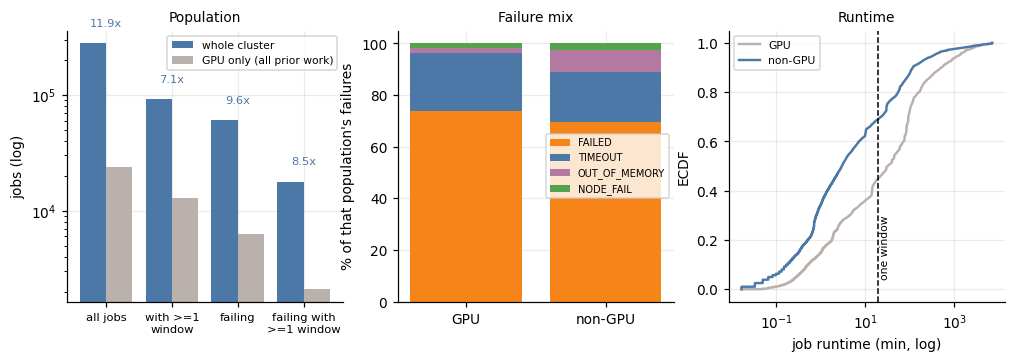

In [11]:
# --- figure: what the population looks like now -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.2))

ax = axes[0]
lv = ["all jobs", "with >=1\nwindow", "failing", "failing with\n>=1 window"]
gpu_v = [int((jobs.gpu_node == 1).sum()),
         int(Wm.loc[Wm.grp == "GPU", "slurm_id"].nunique()),
         int(((jobs.gpu_node == 1) & jobs.is_fail).sum()),
         facts["scorable_failing_jobs_gpu"]]
all_v = [len(jobs), facts["scorable_jobs"], int(jobs.is_fail.sum()),
         facts["scorable_failing_jobs"]]
x = np.arange(len(lv))
ax.bar(x - 0.2, all_v, 0.4, label="whole cluster", color="#4c78a8")
ax.bar(x + 0.2, gpu_v, 0.4, label="GPU only (all prior work)", color="#bab0ac")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(lv, fontsize=7.5)
ax.set_ylabel("jobs (log)"); ax.legend(fontsize=7); ax.set_title("Population", fontsize=9)
for xi, (a_, g_) in enumerate(zip(all_v, gpu_v)):
    ax.text(xi, a_ * 1.4, f"{a_/g_:.1f}x", ha="center", fontsize=7.5, color="#4c78a8")

ax = axes[1]
bot = np.zeros(len(mix))
for st in FAILURE_STATES:
    ax.bar(mix.index, mix[st], bottom=bot, color=COLOR[st], label=st)
    bot += mix[st].to_numpy()
ax.set_ylabel("% of that population's failures")
ax.set_title("Failure mix", fontsize=9); ax.legend(fontsize=6.5, loc="center right")

ax = axes[2]
for g, c in [("GPU", "#bab0ac"), ("non-GPU", "#4c78a8")]:
    d = jobs[(grp == g) & (jobs.duration_s > 0)]
    v = np.sort(d.duration_s.to_numpy() / 60)
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=c, label=g, lw=1.6)
ax.axvline(20, color="k", ls="--", lw=1)
ax.text(22, 0.05, "one window", fontsize=7, rotation=90)
ax.set_xscale("log"); ax.set_xlabel("job runtime (min, log)"); ax.set_ylabel("ECDF")
ax.set_title("Runtime", fontsize=9); ax.legend(fontsize=7)
save(fig, "01_population.png"); plt.show()

## Step 3 - What this changes

The numbers printed above replace the population figures every earlier folder was
working from. Three of them matter for what follows:

* how many **failing jobs can be scored at all** - the denominator behind every
  job-level number in `headroom/`;
* the **window-level positive rate**, which sets the baseline any lift is measured
  against and is therefore not comparable across populations;
* the number of **OUT_OF_MEMORY** jobs, which was 130 and is the one failure mode with
  a demonstrated telemetry precursor.

`02` uses this to run the test the whole folder exists for: hold the protocol fixed and
vary only the amount of data.

In [12]:
facts["jobs_total"] = int(len(jobs))
facts["jobs_failing"] = int(jobs.is_fail.sum())
facts["nodes"] = int(S.node.nunique())
facts["split_time"] = str(SPLIT_TIME)
facts["features"] = FEATURES
json.dump(facts, open(DATA / "facts_01.json", "w"), indent=1)
for k, v in facts.items():
    if k != "features":
        print(f"{k:32s} {v}")

windows                          8045769
windows_gpu                      1057817
windows_nongpu                   6987952
scorable_jobs                    92059
scorable_failing_jobs            17808
scorable_failing_jobs_gpu        2097
positive_rate                    0.04000375849716789
positive_rate_gpu                0.033715661593640485
positive_rate_nongpu             0.040955633352948044
B1                               True
B2                               False
B3                               True
scorable_oom_jobs                1303
scorable_oom_jobs_gpu            57
jobs_total                       280630
jobs_failing                     60450
nodes                            338
split_time                       2022-10-17 12:33:28
